# Evaluate FashionMNIST ViT Checkpoint

This notebook loads a saved `.pth` checkpoint and evaluates it on the Fashion-MNIST test dataset.

**Important:** the model architecture and hyperparameters must match the checkpoint you trained.


In [12]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [13]:
# ====== CONFIG ======
TEST_CSV = "../data/kaggle/fashion-mnist_test.csv"
CHECKPOINT_PATH = "transformers/saved_models_kfold/transformer_v1_fold1_best_loss.pth"

BATCH_SIZE = 64
IMAGE_SIZE = 28
PATCH_SIZE = 7
NUM_CLASSES = 10
DROPOUT = 0.1

# Match these with the checkpoint you want to load.
# transformer_v1 uses these values:
EMBED_DIM = 64
NUM_HEADS = 4
NUM_LAYERS = 4
MLP_DIM = 128

# transformer_v2 hyperparameters
#EMBED_DIM = 32      # down from 64
#NUM_HEADS = 2       # down from 4
#NUM_LAYERS = 2      # down from 4
#MLP_DIM = 64        # down from 128

# transformer_v3 hyperparameters
#EMBED_DIM = 128     # up from 64
#NUM_HEADS = 8       # up from 4
#NUM_LAYERS = 6      # up from 4
#MLP_DIM = 256       # up from 128

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Checkpoint:", CHECKPOINT_PATH)


Using device: cpu
Checkpoint: transformers/saved_models_kfold/transformer_v1_fold1_best_loss.pth


In [14]:
class FashionMNISTCSVDataset(Dataset):
    def __init__(self, csv_file):
        df = pd.read_csv(csv_file)
        self.labels = df.iloc[:, 0].to_numpy(dtype=np.int64)
        self.images = df.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0
        self.images = self.images.reshape(-1, 1, 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


In [15]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size."

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = in_channels * patch_size * patch_size
        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, C, -1, self.patch_size, self.patch_size)
        patches = patches.permute(0, 2, 1, 3, 4).contiguous()
        patches = patches.view(B, self.num_patches, -1)
        embeddings = self.proj(patches)
        return embeddings


class FashionViT(nn.Module):
    def __init__(
        self,
        img_size=28,
        patch_size=7,
        in_channels=1,
        num_classes=10,
        embed_dim=64,
        num_heads=4,
        num_layers=4,
        mlp_dim=128,
        dropout=0.1,
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
        )

        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x)
        cls_output = x[:, 0]
        logits = self.head(cls_output)
        return logits


In [16]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


In [17]:
# Build test loader
pin_memory = torch.cuda.is_available()
test_dataset = FashionMNISTCSVDataset(TEST_CSV)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory)

print("Test dataset size:", len(test_dataset))


Test dataset size: 10000


In [18]:
# Recreate model and load checkpoint
model = FashionViT(
    img_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=1,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    mlp_dim=MLP_DIM,
    dropout=DROPOUT,
).to(device)

state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)

criterion = nn.CrossEntropyLoss()
print("Checkpoint loaded successfully.")


Checkpoint loaded successfully.


In [19]:
# Evaluate on test set
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4%}")


Test Loss: 0.2760
Test Accuracy: 90.0500%


In [20]:
# Detailed classification report
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


              precision    recall  f1-score   support

 T-shirt/top     0.8162    0.8790    0.8464      1000
     Trouser     0.9860    0.9830    0.9845      1000
    Pullover     0.8734    0.8210    0.8464      1000
       Dress     0.8839    0.9360    0.9092      1000
        Coat     0.8280    0.8520    0.8398      1000
      Sandal     0.9927    0.9460    0.9688      1000
       Shirt     0.7782    0.6910    0.7320      1000
     Sneaker     0.9288    0.9520    0.9402      1000
         Bag     0.9703    0.9810    0.9756      1000
  Ankle boot     0.9442    0.9640    0.9540      1000

    accuracy                         0.9005     10000
   macro avg     0.9001    0.9005    0.8997     10000
weighted avg     0.9001    0.9005    0.8997     10000



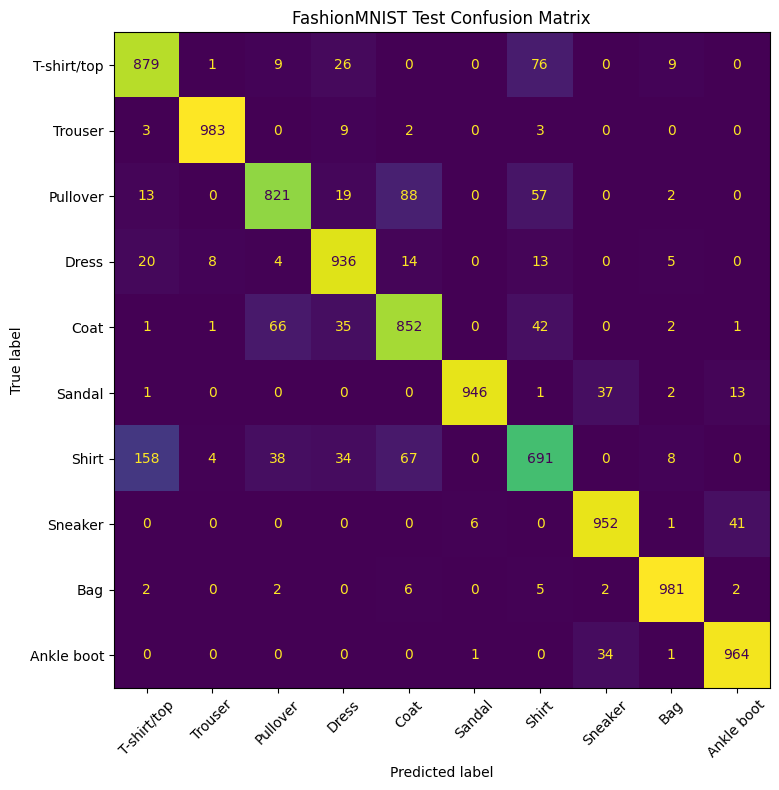

In [21]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False,
)
plt.title("FashionMNIST Test Confusion Matrix")
plt.tight_layout()
plt.show()


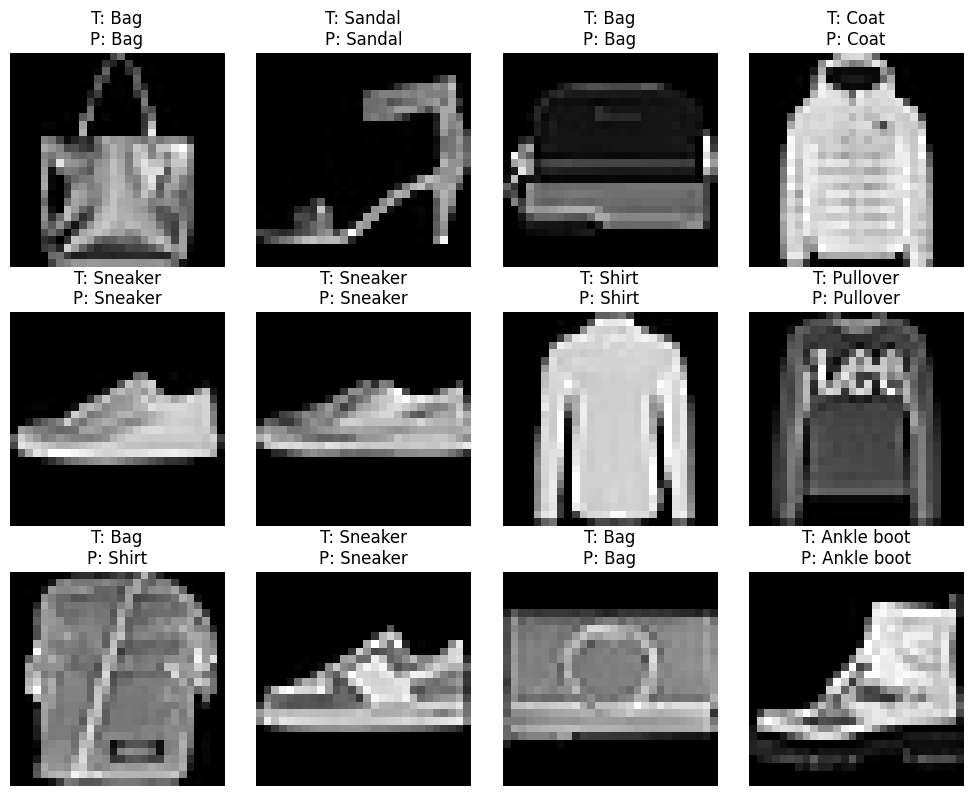

In [22]:
# Show a few sample predictions
num_samples = 12
indices = np.random.choice(len(test_dataset), size=num_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        image, label = test_dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()

        ax.imshow(image.squeeze(0), cmap="gray")
        ax.set_title(f"T: {CLASS_NAMES[label]}\nP: {CLASS_NAMES[pred]}")
        ax.axis("off")

plt.tight_layout()
plt.show()
